In [1]:
import cmocean
import intake
import healpix as hp
import numpy as np
import xarray as xr

/home/users/mmuetz/miniforge3/envs/hackathon_env/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/home/users/mmuetz/miniforge3/envs/hackathon_env/lib/python3.12/site-packages/intake_xarray/base.py:21: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'dims': dict(self._ds.dims),


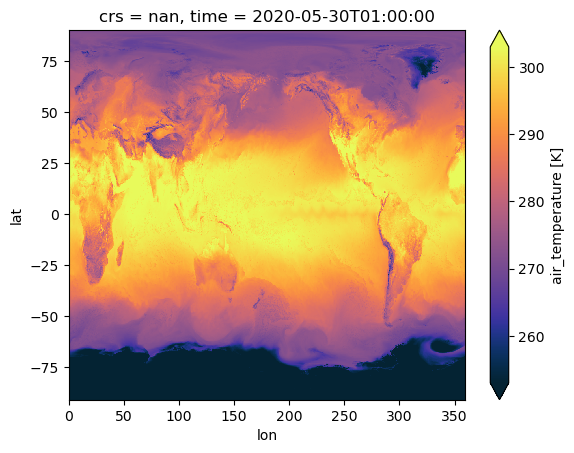

In [2]:
cat = intake.open_catalog('https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml')['online']
data = cat['um_glm_n2560_RAL3p3'](zoom=10, time='PT1H').to_dask()

# Find the HEALPix pixels that are closest to the .2x.2 degree grid points.
# N.B. I had to switch from 1x1 to 0.2x0.2 to get rid of lines at lon=90, 180, 270.
lon = np.arange(0, 360, 0.2)
lat = np.arange(90, -91, -0.2)
pix = xr.DataArray(
    hp.ang2pix(data.crs.healpix_nside, *np.meshgrid(lon, lat), nest=True, lonlat=True),
    coords=(("lat", lat), ("lon", lon)),
)

# Plot the 0.2x0.2 world map for a given variable and time.
data.tas.sel(time="2020-05-30 01:00").isel(cell=pix).plot(
    vmin=253, vmax=303, cmap=cmocean.cm.thermal
)

In [3]:
hp.ang2pix(data.crs.healpix_nside, *np.meshgrid(lon, lat), nest=True, lonlat=True)

array([[ 3145728,  3145728,  3145728, ...,  6291456,  6291456,  6291456],
       [ 2446661,  1048559,  1048559, ...,  4194271,  4194271,  4194271],
       [ 2446613,  1048511,  1048511, ...,  4194175,  4194175,  4194175],
       ...,
       [10485888, 10485888, 10485888, ...,  9437248,  9437248,  9437248],
       [10485922, 10485922, 10485922, ...,  9437265,  9437265,  9437265],
       [10486274, 10486274, 10486274, ...,  9437441,  9437441,  9437441]])